# Merge CSVs on Common ID

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour afficher les graphiques dans le notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')

In [2]:
# Charger tous les fichiers CSV dans un dictionnaire de DataFrames
dataframes = {}

for csv_filename in ['Datasets/Tabular/Binary_pred/dataset1_with_target.csv', 'Datasets/Tabular/Binary_pred/dataset2_features_only.csv']:
    dataframes[csv_filename] = pd.read_csv(csv_filename)
    print(f"Table {csv_filename} shape: {dataframes[csv_filename].shape}")
    print(f"Column names: {dataframes[csv_filename].columns.tolist()}")

# Afficher la liste des DataFrames chargés
list(dataframes.keys())


Table Datasets/Tabular/Binary_pred/dataset1_with_target.csv shape: (10000, 11)
Column names: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'YTarget', 'ID']
Table Datasets/Tabular/Binary_pred/dataset2_features_only.csv shape: (10000, 10)
Column names: ['Extra_Feature_1', 'Extra_Feature_2', 'Extra_Feature_3', 'Extra_Feature_4', 'Extra_Feature_5', 'Extra_Feature_6', 'Extra_Feature_7', 'Extra_Feature_8', 'Extra_Feature_9', 'ID']


['Datasets/Tabular/Binary_pred/dataset1_with_target.csv',
 'Datasets/Tabular/Binary_pred/dataset2_features_only.csv']

In [3]:
# Fusionner tous les DataFrames sur la colonne d'ID commune
merged_df = None

for df_name, df in dataframes.items():
    if "ID" not in df.columns:
        print(f"Attention: La colonne 'ID' n'est pas présente dans {df_name}")
        continue
        
    if merged_df is None:
        merged_df = df.copy()
    else:
        # Utiliser un suffixe pour éviter la duplication des noms de colonnes
        merged_df = pd.merge(merged_df, df, on="ID", how='outer', 
                            suffixes=('', f'_{df_name}'))
# Standardize merged df
df = merged_df

# Afficher des informations sur le DataFrame fusionné
print("Shape du DataFrame final:", df.shape)
print("Colonnes du DataFrame final:", df.columns.tolist())
df.head()


Shape du DataFrame final: (10000, 20)
Colonnes du DataFrame final: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'YTarget', 'ID', 'Extra_Feature_1', 'Extra_Feature_2', 'Extra_Feature_3', 'Extra_Feature_4', 'Extra_Feature_5', 'Extra_Feature_6', 'Extra_Feature_7', 'Extra_Feature_8', 'Extra_Feature_9']


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,YTarget,ID,Extra_Feature_1,Extra_Feature_2,Extra_Feature_3,Extra_Feature_4,Extra_Feature_5,Extra_Feature_6,Extra_Feature_7,Extra_Feature_8,Extra_Feature_9
0,0.449907,0.416257,-1.570976,2.555913,-0.107989,1.064232,1.398215,1.655080,-0.489670,1,1,0.687812,-0.867655,0.884511,-0.270227,-0.811306,1.213174,-0.188874,2.687045,0.322899
1,-3.045416,0.762539,0.767025,-1.604895,0.416488,1.841529,-0.224509,1.308288,-2.448869,0,2,-1.120926,0.578970,0.142980,-0.473737,0.532608,-1.834851,0.845767,-1.513882,-0.547689
2,-1.182084,0.505153,-2.115420,1.655839,-0.167917,-1.493899,1.677856,-0.545578,-1.744191,1,3,-0.066408,1.969714,-0.092239,0.717932,-0.791414,-1.007941,0.399049,-1.098553,-1.187068
3,-2.044690,1.168372,0.214280,1.878548,-0.379547,-0.236619,-1.503940,0.890020,-1.138879,1,4,-0.093083,2.099958,-1.796247,-0.145777,-0.394601,-1.090318,2.583619,0.675000,-0.784924
4,-3.321669,1.999744,1.828838,2.016663,0.291406,1.338508,0.306080,1.441312,-0.409007,1,5,-0.155528,1.813501,0.388034,-0.681848,0.520442,0.523967,0.999795,-1.644745,0.199010


# Random Forest

In [4]:
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
target_column = "YTarget"
num_classes = 2

# Split the data
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[target_column]), df[target_column], test_size=0.2, random_state=42)

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# Set parameters for XGBoost with better defaults
params = {
    'objective': 'multi:softmax',
    'num_class': num_classes,
    'max_depth': 6,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'eval_metric': 'mlogloss'
}

# Train the model with early stopping
num_rounds = 1000
eval_list = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(params, dtrain, num_rounds, eval_list,
               early_stopping_rounds=20, verbose_eval=100)


[0]	train-mlogloss:0.63239	eval-mlogloss:0.63516


/Users/eliottvalette/Library/Mobile Documents/com~apple~CloudDocs/Documents/Codage /NoteBook Maker/.venv/lib/python3.10/site-packages/xgboost/core.py:726: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[100]	train-mlogloss:0.07132	eval-mlogloss:0.16803


[166]	train-mlogloss:0.03856	eval-mlogloss:0.16755


Accuracy: 0.9345

Classification Report:


              precision    recall  f1-score   support

           0       0.93      0.93      0.93       975
           1       0.93      0.94      0.94      1025

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



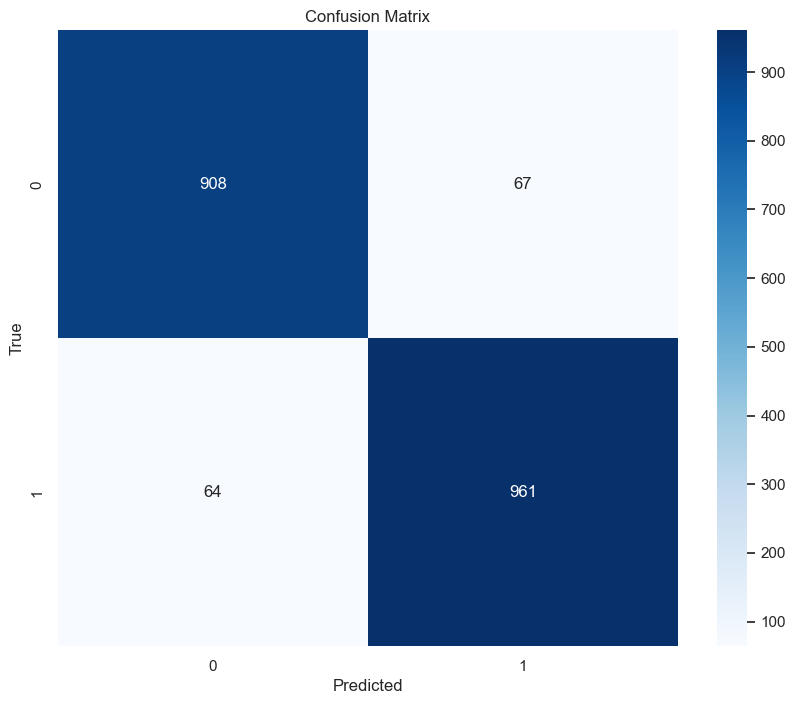

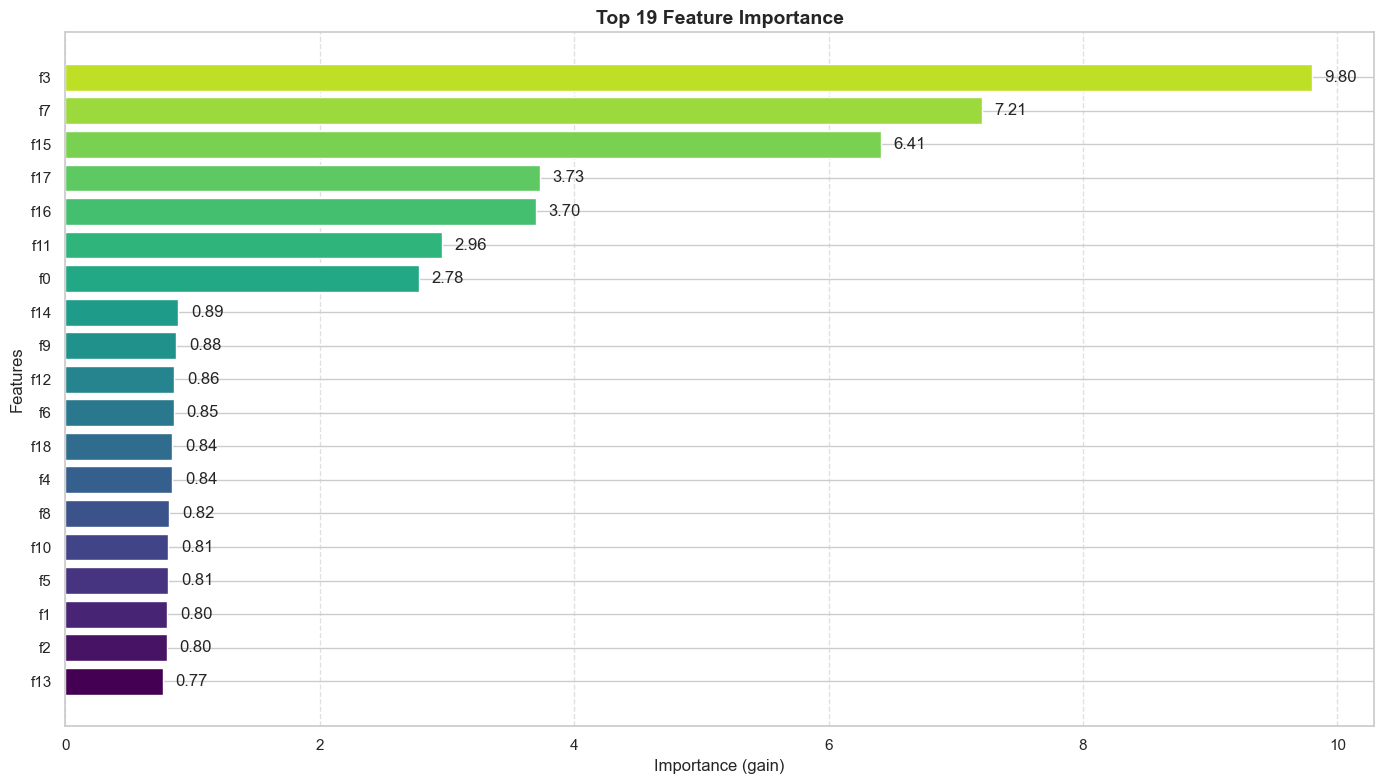

In [6]:
# Make predictions
y_pred = model.predict(dtest)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Feature importance with better visualization
plt.figure(figsize=(14, 8))

# Get feature importance
importance = model.get_score(importance_type='gain')
features = list(importance.keys())
scores = list(importance.values())

# Sort by importance
indices = np.argsort(scores)[-20:]  # Top 20 features

# Create colorful horizontal bar chart
colors = plt.cm.viridis(np.linspace(0, 0.9, len(indices)))
plt.barh(range(len(indices)), [scores[i] for i in indices], color=colors)
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance (gain)')
plt.ylabel('Features')
plt.title(f'Top {min(20, len(features))} Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add values on bars
for i, v in enumerate([scores[idx] for idx in indices]):
    plt.text(v + 0.1, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()
